# Preliminaries

## The plan:
The plan of the project will be iterative, where we will merge the VAE notebook and the diffusion project, with appropriate modifications made for the new setting of latent diffusion. We will be working off the Wikipedia article: https://en.wikipedia.org/wiki/Latent_diffusion_model, which outlines some of the core aspects of the project. We will (preliminarily) use ~~the Caltech-256 dataset~~. We will use the Flowers101 dataset.

https://docs.pytorch.org/vision/2.0/generated/torchvision.datasets.LSUN.html

In [1]:
# Begin with some imports
import torch
import torch.optim as optim 
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn.functional as F 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# Get training data
# Apply some transforms to get uniform images. 
training_data = datasets.Flowers102(
    root="data",
    download=True,
    transform=transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
)
# 4 should be fine as we have 1 GPU, batch size decreased as the images are much bigger. 
train_loader = DataLoader(dataset=training_data, 
                          batch_size=32,
                          num_workers=4,
                          shuffle=True)

# Dataset visualisation

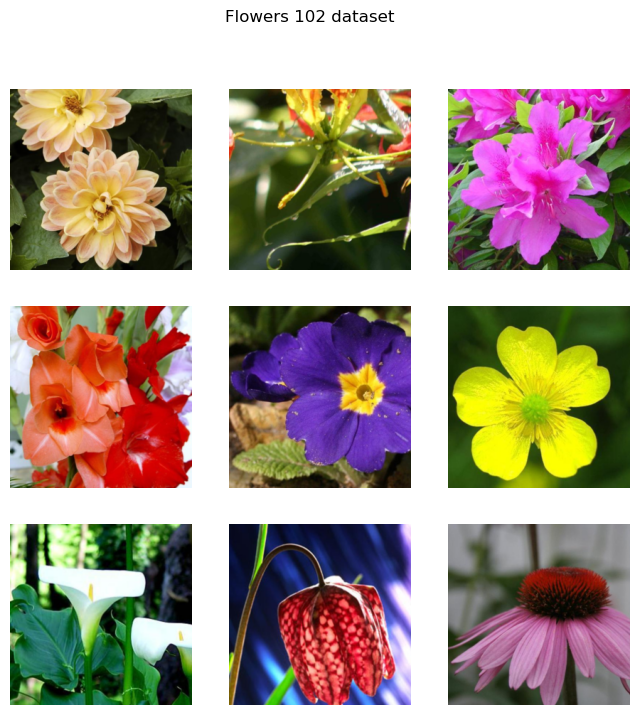

In [4]:
# just a quick plot to visualise the dataset
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    # note structure: IMAGE, LABEL¨
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0))
figure.suptitle("Flowers 102 dataset")
plt.show()

In [5]:
# utility functions

# loss function for the VAE, same as in the VAE notebook. 
def loss_function_VAE(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss.mean()

# TODO: port over nosie scheduler, etc. 

# The plan

First we have to train the VAE. We need to alter the structure from the previous notebooks as we will be using diffusion on the latent space, so we will get rid of the overarching class. Then once training is done, we will need to save the model weights. Note that we also need to possibly make further alterations to the Enoder/Decoder structure. We annotate changes where possible. 

In [6]:
# Define model, encoder decoder seperately

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        # we know that the images are 256x256, so we do not need any special handling.
        hidden_dim= 128*(256//8)*(256//8)
        self.f_mu = nn.Linear(hidden_dim,latent_dim)
        self.f_logvar = nn.Linear(hidden_dim,latent_dim)

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

    # needed to make the gradients flow. Compared to the other notebook, we define this here. This is so that we can train the diffusion model in the latent space (this is my understanding of how latent diffusion works)
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self,x):
        x = self.encoder_stack(x)
        mu = self.f_mu(x)
        f_logvar = self.f_logvar(x)
        z = self.reparameterise(mu, f_logvar)
        # returns z here - we change variables so that it is clearer what we are doing. 
        return z, mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        hidden_dim = 128*(256//8)*(256//8)
        #display(hidden_dim)
        pre_flatten_shape = (128, 32, 32)
        # fully connected layer
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        # define a helper to reshape to allow for tensor operations
        self.reshape = lambda x: x.view(-1, *pre_flatten_shape)

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        x = self.fc1(x)
        x = self.reshape(x)
        
        x = self.decoder_stack(x)
        
        return x


In [ ]:
epochs = 100
learning_rate = 1e-3

# we will go with 2048 latent dimensions for now
encoder = Encoder(latent_dim=128).to(device)
decoder = Decoder(latent_dim=128).to(device)

optimizer = torch.optim.AdamW(list(encoder.parameters())+list(decoder.parameters()),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)


train_losses = []

encoder.train()
decoder.train()


for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)
        optimizer.zero_grad()
        z, mu, logvar = encoder(x)
        recon_x = decoder(z)

        loss = loss_function_VAE(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()




TypeError: can't multiply sequence by non-int of type 'float'

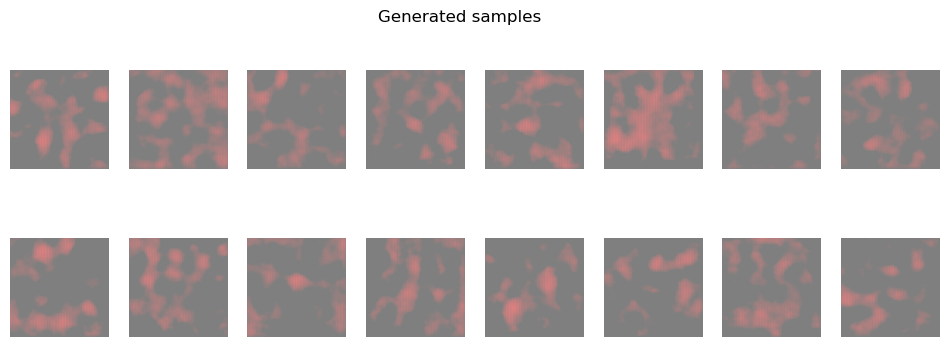

In [11]:
encoder.eval()
decoder.eval()


with torch.no_grad():
    z = torch.randn((16,128)).to(device)

    generated = decoder(z).cpu()

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1,2,0))
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()